In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import os

# Set up visualization style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [ ]:
# Load the data
df = pd.read_csv('cleaned_dataset.csv')
df

,ActivitySiteID,ActivityDescription,BookingEndDateTime,BookingStartTime,MaxBookees,Number Booked,PriceINR,Hour,Month,Week,DayOfWeek,DayOfWeekNum,occupancy_rate
0,HXP,20-20-20 2.45pm-3.45pm,2018-04-08,14:45:00,-0.48,-0.54,-1.71,14,4,14,Sunday,6,0.48
1,HXP,20-20-20 2.45pm-3.45pm,2018-04-15,14:45:00,-0.48,-0.22,-1.71,14,4,15,Sunday,6,0.60
2,HXP,20-20-20 2.45pm-3.45pm,2018-04-22,14:45:00,-0.48,-0.33,-1.71,14,4,16,Sunday,6,0.56
3,HXP,20-20-20 2.45pm-3.45pm,2018-04-29,14:45:00,-0.48,-0.85,-1.71,14,4,17,Sunday,6,0.36
4,HXP,20-20-20 2.45pm-3.45pm,2018-05-06,14:45:00,-0.48,-1.06,-1.71,14,5,18,Sunday,6,0.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3266,TSC,zumba 6.30-7.30pm,2018-06-18,18:30:00,-0.94,-0.85,-0.70,18,6,25,Monday,0,0.50
3267,TSC,zumba 6.30-7.30pm,2018-06-25,18:30:00,-0.94,-0.85,-0.70,18,6,26,Monday,0,0.50
3268,TSC,zumba - 6-7pm,2018-06-07,18:00:00,1.18,-0.12,-0.70,18,6,23,Thursday,3,0.32
3269,TSC,zumba - 6-7pm,2018-06-14,18:00:00,1.18,-0.43,-0.70,18,6,24,Thursday,3,0.26


In [ ]:
# # 2.1 Feature Extraction
# df['BookingEndDateTime'] = pd.to_datetime(df['BookingEndDateTime'])
# df['weekday'] = df['BookingEndDateTime'].dt.day_name()
# df['Month'] = df['BookingEndDateTime'].dt.month_name()

In [ ]:
df

,ActivitySiteID,ActivityDescription,BookingEndDateTime,BookingStartTime,MaxBookees,Number Booked,PriceINR,Hour,Month,Week,DayOfWeek,DayOfWeekNum,occupancy_rate
0,HXP,20-20-20 2.45pm-3.45pm,2018-04-08,14:45:00,-0.48,-0.54,-1.71,14,4,14,Sunday,6,0.48
1,HXP,20-20-20 2.45pm-3.45pm,2018-04-15,14:45:00,-0.48,-0.22,-1.71,14,4,15,Sunday,6,0.60
2,HXP,20-20-20 2.45pm-3.45pm,2018-04-22,14:45:00,-0.48,-0.33,-1.71,14,4,16,Sunday,6,0.56
3,HXP,20-20-20 2.45pm-3.45pm,2018-04-29,14:45:00,-0.48,-0.85,-1.71,14,4,17,Sunday,6,0.36
4,HXP,20-20-20 2.45pm-3.45pm,2018-05-06,14:45:00,-0.48,-1.06,-1.71,14,5,18,Sunday,6,0.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3266,TSC,zumba 6.30-7.30pm,2018-06-18,18:30:00,-0.94,-0.85,-0.70,18,6,25,Monday,0,0.50
3267,TSC,zumba 6.30-7.30pm,2018-06-25,18:30:00,-0.94,-0.85,-0.70,18,6,26,Monday,0,0.50
3268,TSC,zumba - 6-7pm,2018-06-07,18:00:00,1.18,-0.12,-0.70,18,6,23,Thursday,3,0.32
3269,TSC,zumba - 6-7pm,2018-06-14,18:00:00,1.18,-0.43,-0.70,18,6,24,Thursday,3,0.26


In [ ]:
daily_trend = df.groupby('ActivityDescription')['ActivitySiteID']
daily_trend

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe().sum()

,0
MaxBookees,3271.989716
Number Booked,3275.090063
PriceINR,3272.670813
Hour,3353.291180
Month,3301.829837
Week,3393.765461
DayOfWeekNum,3288.151898
occupancy_rate,3278.773140


  Saved Line Plot: eda_plots/daily_bookings_lineplot.png


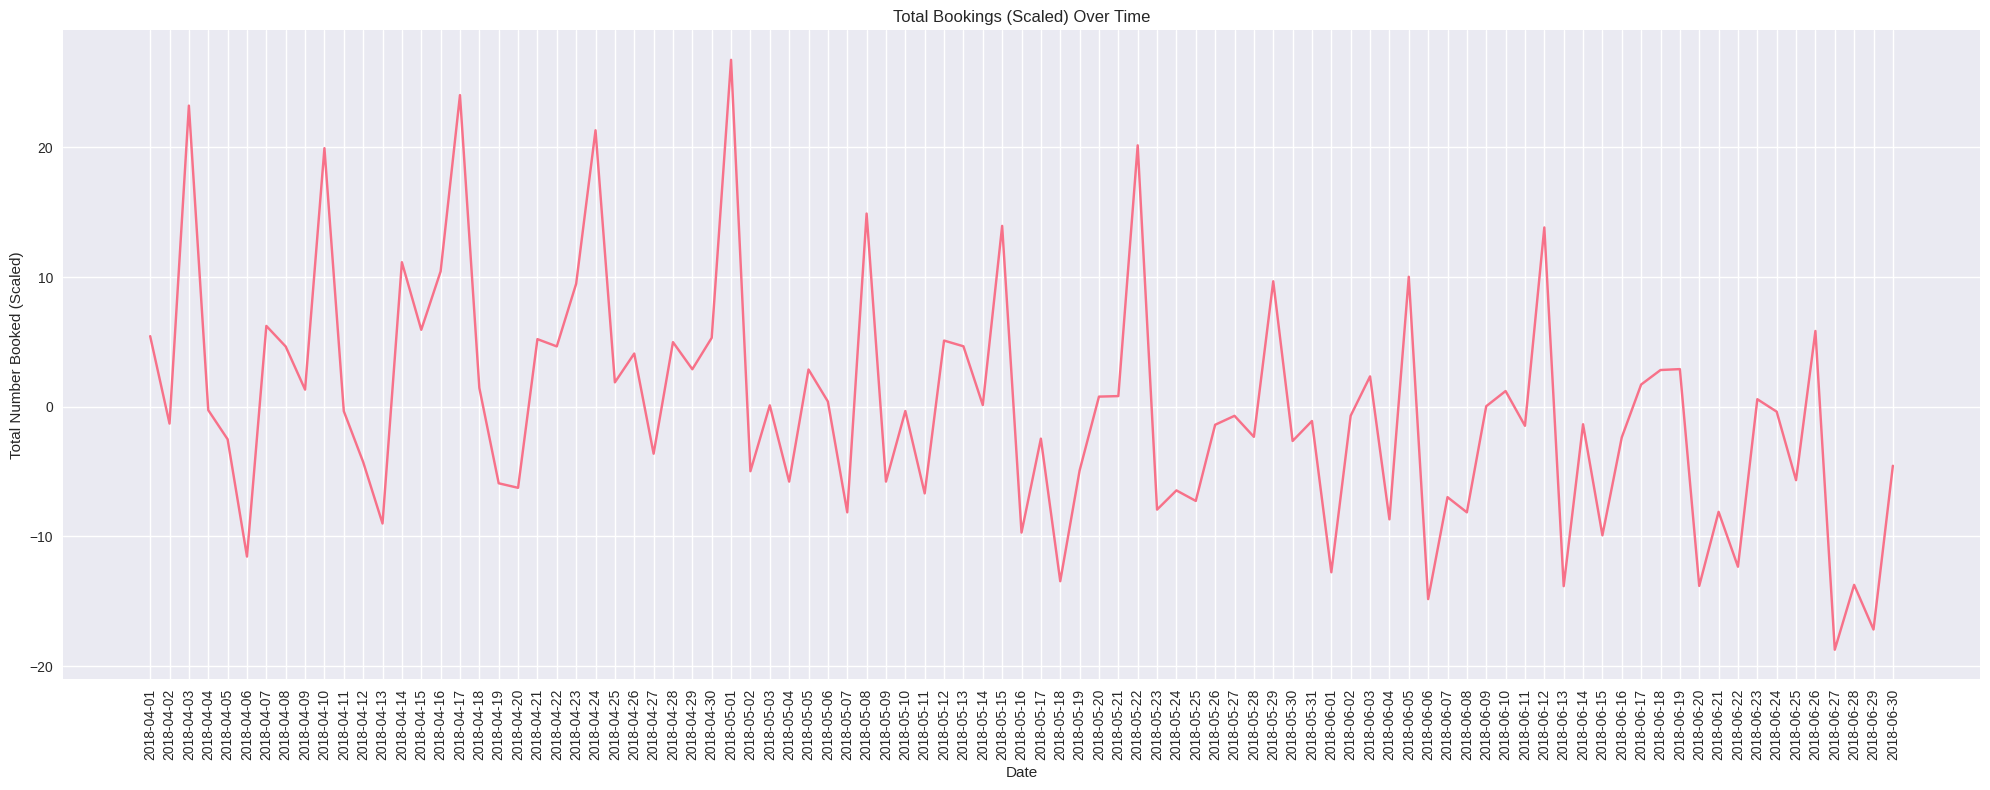

In [ ]:
daily_bookings = df.groupby('BookingEndDateTime')['Number Booked'].sum().reset_index()
plt.figure(figsize=(20, 8))
sns.lineplot(x='BookingEndDateTime', y='Number Booked', data=daily_bookings)
plt.title('Total Bookings (Scaled) Over Time')
plt.xlabel('Date')
plt.ylabel('Total Number Booked (Scaled)')
plt.xticks(rotation=90)
plt.tight_layout()

# Corrected: Using a relative path suitable for Colab and a descriptive filename
plots_dir = "eda_plots"
os.makedirs(plots_dir, exist_ok=True) # Ensure the directory exists
plot_path = os.path.join(plots_dir, 'daily_bookings_lineplot.png')

plt.savefig(plot_path)
print(f"  Saved Line Plot: {plot_path}")
plt.show() # Display the plot
plt.close() # Close the plot figure after displaying

In [ ]:
# # Focus on the unscaled Utilization_Rate for meaningful outlier detection
# plt.figure(figsize=(6, 3))
# sns.boxplot(y=df['occupancy_rate'])
# plt.title('Box Plot of Utilization Rate')
# plt.tight_layout()
# plt.show()

Text(0.5, 1.0, 'Price (z-score) vs Occupancy Rate')

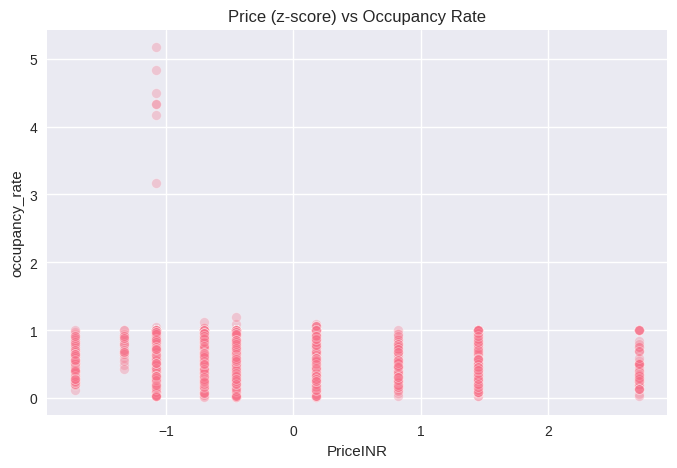

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='PriceINR', y='occupancy_rate', data=df, alpha=0.3)
plt.title('Price (z-score) vs Occupancy Rate')

  Saved Line Plot: eda_plots/Day of Week.png


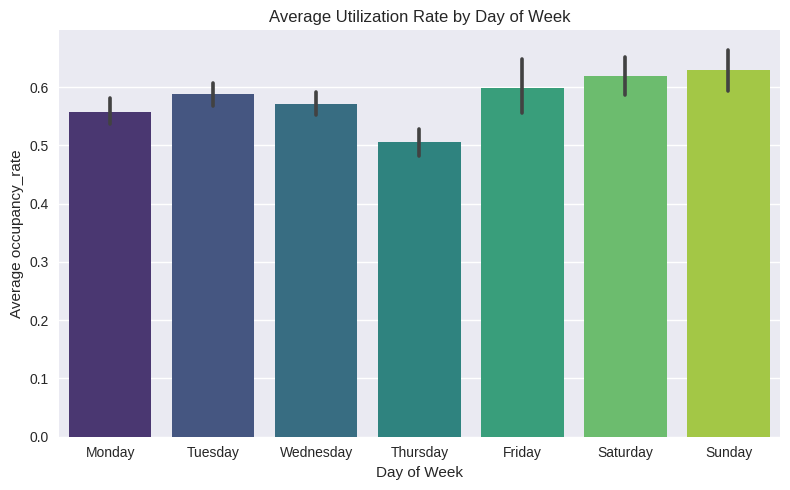

In [ ]:
# Day of Week

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(8, 5))
sns.barplot(x='DayOfWeek', y='occupancy_rate', data=df, estimator=np.mean, order=day_order, palette='viridis')
plt.title('Average Utilization Rate by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average occupancy_rate')
plt.tight_layout()
# Corrected: Using a relative path suitable for Colab and a descriptive filename
plots_dir = "eda_plots"
# os.makedirs(plots_dir, exist_ok=True) # This directory is already created in a previous cell
plot_path = os.path.join(plots_dir, 'Day of Week.png')

plt.savefig(plot_path)
print(f"  Saved Line Plot: {plot_path}")
plt.show() # Display the plot
plt.close() # Close the plot figure after displaying

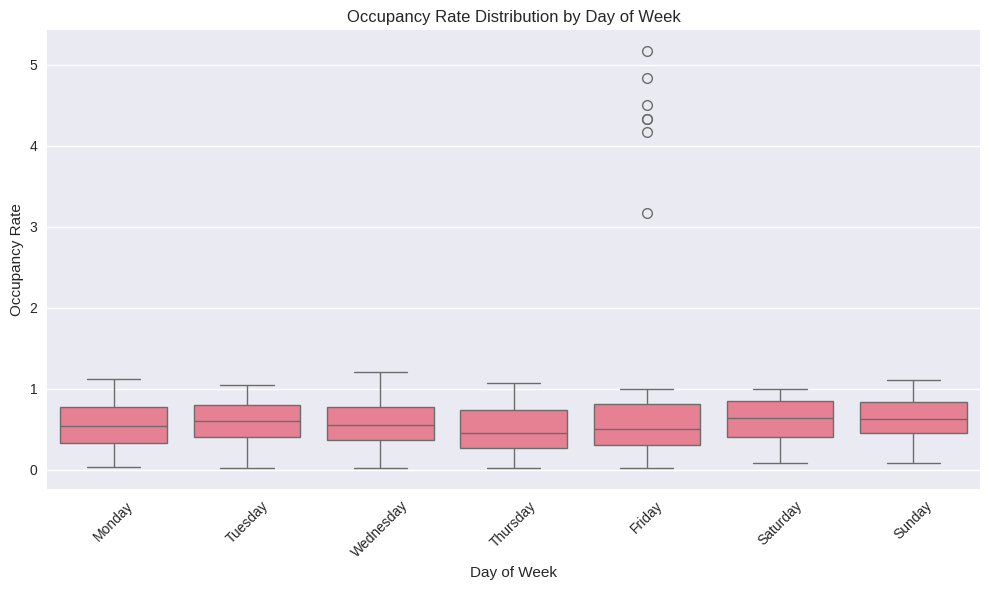

Saved: eda_plots/occupancy_by_dayofweek.png


In [ ]:
# Demand by Day of Week ---
# Order the days of the week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['DayOfWeek'] = pd.Categorical(df['DayOfWeek'], categories=day_order, ordered=True)

plt.figure(figsize=(10, 6))
sns.boxplot(x='DayOfWeek', y='occupancy_rate', data=df)
plt.title('Occupancy Rate Distribution by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Occupancy Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'occupancy_by_dayofweek.png'))
plt.show()
plt.close()
print(f"Saved: {plots_dir}/occupancy_by_dayofweek.png")

  Saved Line Plot: eda_plots/Time-of-Day Trend.png


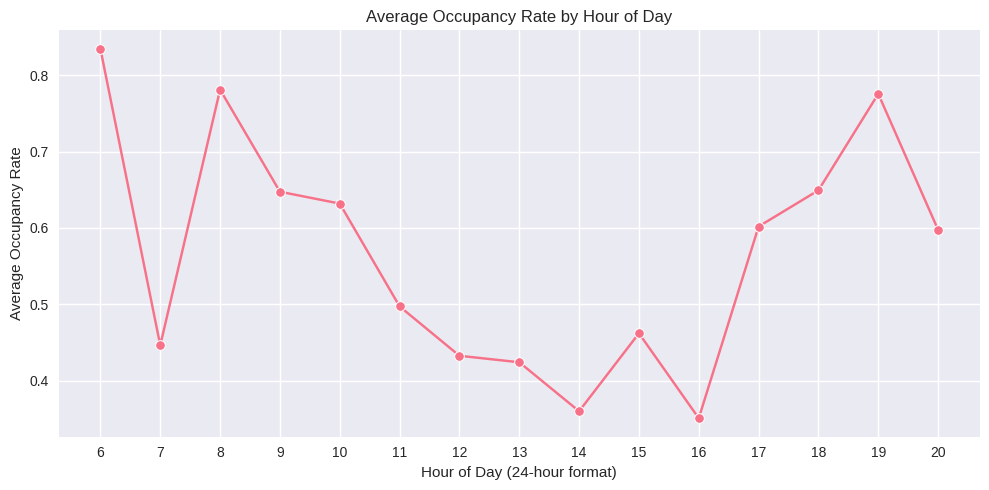

In [ ]:
# --- 2. Demand by Hour of Day (Time-of-Day Trend) ---
plt.figure(figsize=(10, 5))
hourly_demand = df.groupby('Hour')['occupancy_rate'].mean().reset_index()
sns.lineplot(x='Hour', y='occupancy_rate', data=hourly_demand, marker='o')
plt.title('Average Occupancy Rate by Hour of Day')
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Average Occupancy Rate')
plt.xticks(range(df['Hour'].min(), df['Hour'].max() + 1))
plt.tight_layout()
# Corrected: Using a relative path suitable for Colab and a descriptive filename
plots_dir = "eda_plots"
# os.makedirs(plots_dir, exist_ok=True) # This directory is already created in a previous cell
plot_path = os.path.join(plots_dir, 'Time-of-Day Trend.png')

plt.savefig(plot_path)
print(f"  Saved Line Plot: {plot_path}")
plt.show() # Display the plot
plt.close() # Close the plot figure after displaying

  Saved Line Plot: eda_plots/Seasonal Trend by Week.png


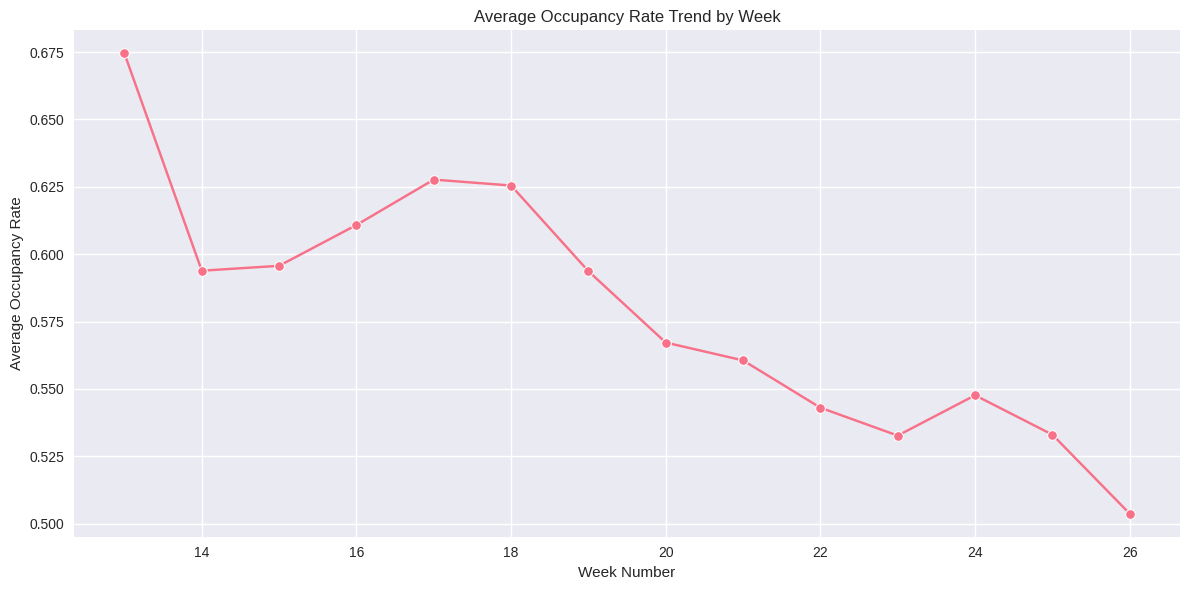

In [ ]:
# --- 3. Seasonal Trend by Week ---
plt.figure(figsize=(12, 6))
weekly_demand = df.groupby('Week')['occupancy_rate'].mean().reset_index()
sns.lineplot(x='Week', y='occupancy_rate', data=weekly_demand, marker='o')
plt.title('Average Occupancy Rate Trend by Week')
plt.xlabel('Week Number')
plt.ylabel('Average Occupancy Rate')
plt.tight_layout()
# Corrected: Using a relative path suitable for Colab and a descriptive filename
plots_dir = "eda_plots"
# os.makedirs(plots_dir, exist_ok=True) # This directory is already created in a previous cell
plot_path = os.path.join(plots_dir, 'Seasonal Trend by Week.png')

plt.savefig(plot_path)
print(f"  Saved Line Plot: {plot_path}")
plt.show() # Display the plot
plt.close() # Close the plot figure after displaying

Top High-Demand Classes

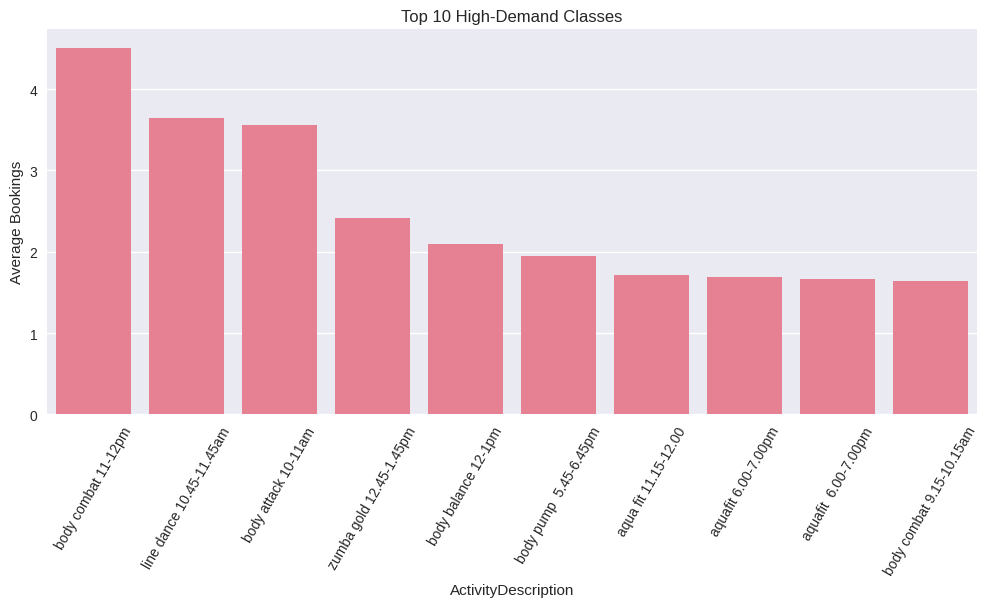

In [ ]:
plt.figure(figsize=(12,5))
top_classes = df.groupby("ActivityDescription")['Number Booked'].mean().sort_values(ascending=False).head(10)

sns.barplot(x=top_classes.index, y=top_classes.values)
plt.title("Top 10 High-Demand Classes")
plt.xticks(rotation=60)
plt.ylabel("Average Bookings")
plt.show()

Top **10** High Classes occupancy

  Saved Line Plot: eda_plots/Top **10** High Classes occupancy.png


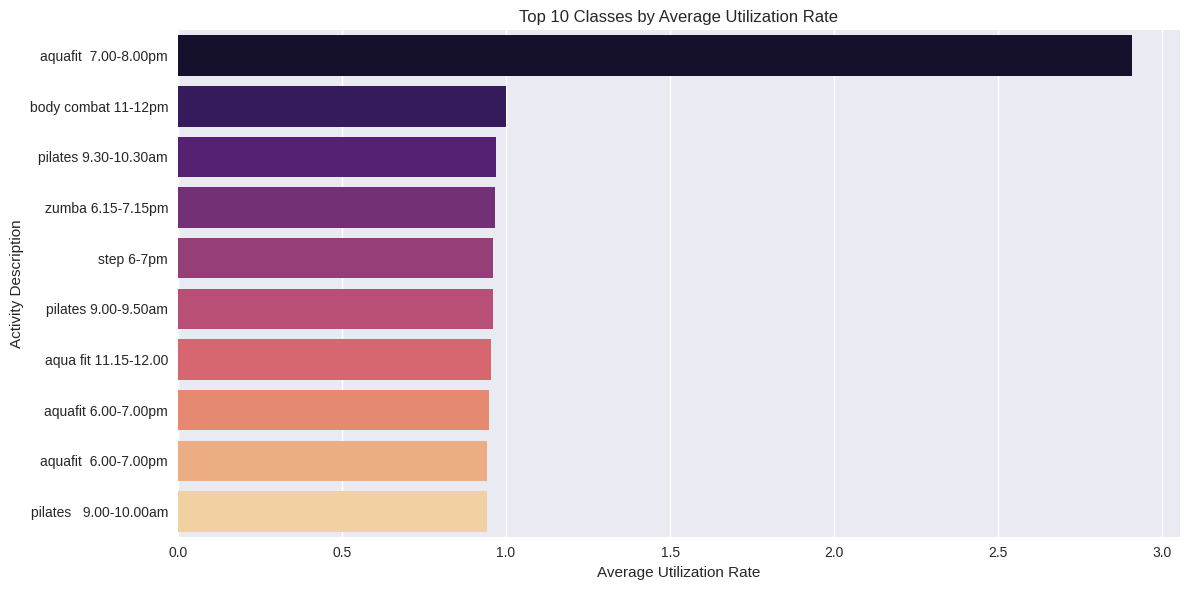

In [ ]:
top_classes_occupancy = df.groupby('ActivityDescription')['occupancy_rate'].mean().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='occupancy_rate', y='ActivityDescription', data=top_classes_occupancy, palette='magma')
plt.title('Top 10 Classes by Average Utilization Rate')
plt.xlabel('Average Utilization Rate')
plt.ylabel('Activity Description')
plt.tight_layout()
# Corrected: Using a relative path suitable for Colab and a descriptive filename
plots_dir = "eda_plots"
# os.makedirs(plots_dir, exist_ok=True) # This directory is already created in a previous cell
plot_path = os.path.join(plots_dir, 'Top **10** High Classes occupancy.png')

plt.savefig(plot_path)
print(f"  Saved Line Plot: {plot_path}")
plt.show() # Display the plot
plt.close() # Close the plot figure after displaying

simple and easy to understand Price Elasticity Model

--- Outlier Analysis using IQR Method ---

Feature: MaxBookees
  IQR: 0.7200
  Lower Bound: -1.6200
  Upper Bound: 1.2600
  Outlier Count: 550
  Outlier Percentage: 16.81%


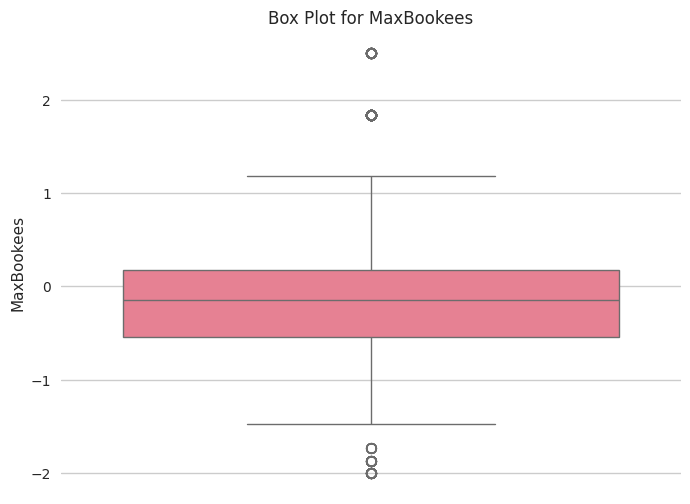

  Saved Box Plot: eda_plots/boxplot_MaxBookees.png

Feature: Number Booked
  IQR: 1.4700
  Lower Bound: -2.9550
  Upper Bound: 2.9250
  Outlier Count: 22
  Outlier Percentage: 0.67%


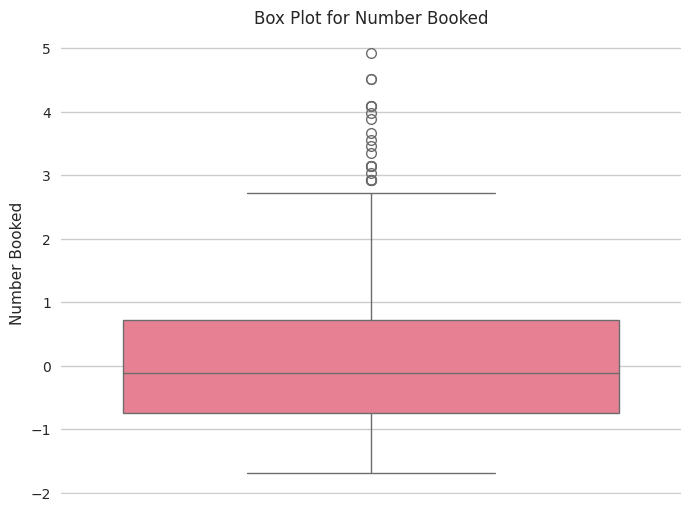

  Saved Box Plot: eda_plots/boxplot_Number Booked.png

Feature: PriceINR
  IQR: 1.5200
  Lower Bound: -2.9800
  Upper Bound: 3.1000
  Outlier Count: 0
  Outlier Percentage: 0.00%


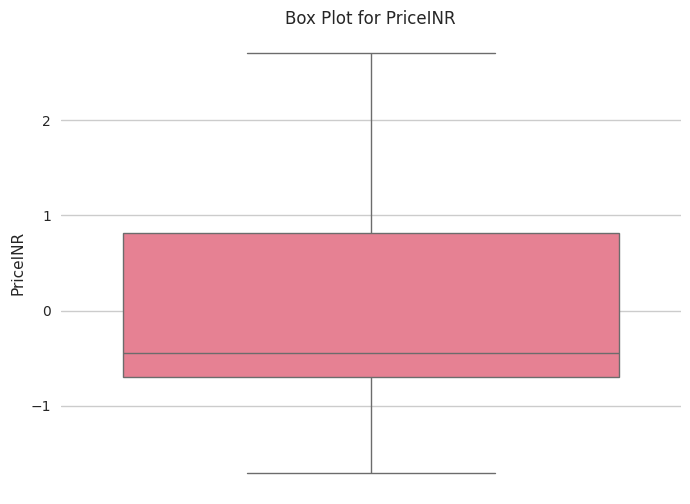

  Saved Box Plot: eda_plots/boxplot_PriceINR.png

Feature: occupancy_rate
  IQR: 0.4571
  Lower Bound: -0.3429
  Upper Bound: 1.4857
  Outlier Count: 7
  Outlier Percentage: 0.21%


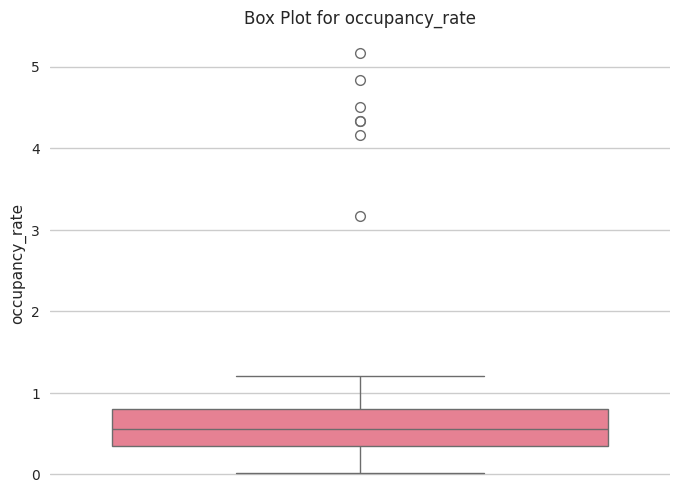

  Saved Box Plot: eda_plots/boxplot_occupancy_rate.png


In [ ]:
# Set up the visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Create a directory for saving plots
plots_dir = "eda_plots"
os.makedirs(plots_dir, exist_ok=True)

# Key numerical features for outlier analysis
numerical_features = ['MaxBookees', 'Number Booked', 'PriceINR', 'occupancy_rate']
outlier_summary = {}

print("--- Outlier Analysis using IQR Method ---")

for col in numerical_features:
    # --- 1. Statistical Outlier Detection (IQR Method) ---
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df)) * 100

    outlier_summary[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': outlier_count,
        'Outlier Percentage': f"{outlier_percentage:.2f}%"
    }

    print(f"\nFeature: {col}")
    print(f"  IQR: {IQR:.4f}")
    print(f"  Lower Bound: {lower_bound:.4f}")
    print(f"  Upper Bound: {upper_bound:.4f}")
    print(f"  Outlier Count: {outlier_count}")
    print(f"  Outlier Percentage: {outlier_percentage:.2f}%")

    # --- 2. Visual Outlier Detection (Box Plot) ---
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot for {col}')
    plt.ylabel(col)
    plot_path = os.path.join(plots_dir, f'boxplot_{col}.png')
    plt.savefig(plot_path)
    plt.show()
    print(f"  Saved Box Plot: {plot_path}")

In [ ]:
# Save the statistical summary to a file
outlier_df = pd.DataFrame(outlier_summary).T
outlier_df = outlier_df[['Q1', 'Q3', 'IQR', 'Lower Bound', 'Upper Bound', 'Outlier Count', 'Outlier Percentage']]
with open("outlier_analysis_summary.md", "w") as f:
    f.write("## Outlier Analysis Summary (IQR Method)\n\n")
    f.write("The Interquartile Range (IQR) method was used to identify potential outliers, where values fall below $Q1 - 1.5 \\times IQR$ or above $Q3 + 1.5 \\times IQR$.\n\n")
    f.write(outlier_df.to_markdown(numalign="left", stralign="left"))

print("\nOutlier analysis complete. Summary saved to outlier_analysis_summary.md.")


Outlier analysis complete. Summary saved to outlier_analysis_summary.md.


In [ ]:
# Basic info
print(df.shape)        # (32xxx, 13)
print(df['ActivitySiteID'].nunique())   # 7 sites: HXP, TSC, NBL, SBP, BRP, etc.
print(df['ActivityDescription'].nunique())  # 150+ unique class types

(3271, 13)
5
280


In [ ]:
# --- 1. Descriptive Statistics for Numerical Columns ---
numerical_cols = ['MaxBookees', 'Number Booked', 'PriceINR', 'Hour', 'Month', 'Week', 'DayOfWeekNum', 'occupancy_rate']
desc_stats = df[numerical_cols].describe().T

# Add a note about the scaled data
print("--- Descriptive Statistics for Numerical Columns ---")
print("NOTE: 'MaxBookees', 'Number Booked', and 'PriceINR' appear to be scaled/standardized, as indicated by their small mean and standard deviation, and negative values.")
print(desc_stats.to_markdown(numalign="left", stralign="left"))

# Save descriptive statistics to a file
with open("descriptive_statistics.md", "w") as f:
    f.write("## Descriptive Statistics\n\n")
    f.write("NOTE: 'MaxBookees', 'Number Booked', and 'PriceINR' appear to be scaled/standardized, as indicated by their small mean and standard deviation, and negative values.\n\n")
    f.write(desc_stats.to_markdown(numalign="left", stralign="left"))

--- Descriptive Statistics for Numerical Columns ---
NOTE: 'MaxBookees', 'Number Booked', and 'PriceINR' appear to be scaled/standardized, as indicated by their small mean and standard deviation, and negative values.
|                | count   | mean        | std      | min       | 25%      | 50%      | 75%   | max     |
|:---------------|:--------|:------------|:---------|:----------|:---------|:---------|:------|:--------|
| MaxBookees     | 3271    | -0.00119535 | 1.00091  | -2        | -0.54    | -0.15    | 0.18  | 2.5     |
| Number Booked  | 3271    | 0.000819321 | 0.999243 | -1.69     | -0.75    | -0.12    | 0.72  | 4.93    |
| PriceINR       | 3271    | -0.00143076 | 1.00224  | -1.71     | -0.7     | -0.45    | 0.82  | 2.71    |
| Hour           | 3271    | 13.3702     | 3.92096  | 6         | 10       | 12       | 17    | 20      |
| Month          | 3271    | 5.01345     | 0.816386 | 4         | 4        | 5        | 6     | 6       |
| Week           | 3271    | 20.0061     

In [ ]:
# --- 2. Analysis of Categorical Columns ---
categorical_cols = ['ActivitySiteID', 'ActivityDescription', 'DayOfWeek']
categorical_analysis = {}

print("\n--- Analysis of Categorical Columns ---")
for col in categorical_cols:
    print(f"\n--- {col} Value Counts (Top 10) ---")
    value_counts = df[col].value_counts().head(10)
    print(value_counts.to_markdown(numalign="left", stralign="left"))
    categorical_analysis[col] = value_counts


--- Analysis of Categorical Columns ---

--- ActivitySiteID Value Counts (Top 10) ---
| ActivitySiteID   | count   |
|:-----------------|:--------|
| HXP              | 771     |
| SBP              | 731     |
| BRP              | 727     |
| NBL              | 529     |
| TSC              | 513     |

--- ActivityDescription Value Counts (Top 10) ---
| ActivityDescription       | count   |
|:--------------------------|:--------|
| body conditioning 10-11am | 39      |
| body balance 11-12pm      | 35      |
| aquafit 7.00-8.00pm       | 35      |
| body combat 7.00-8.00pm   | 33      |
| jnr gym appoint 4-5pm     | 31      |
| pilates 9.30-10.30am      | 26      |
| studio cyc 5.00-5.50pm    | 26      |
| aquafit 7.15-8.15pm       | 26      |
| studio cyc 7.05-7.55am    | 26      |
| 20-20-20 9.30-10.30am     | 26      |

--- DayOfWeek Value Counts (Top 10) ---
| DayOfWeek   | count   |
|:------------|:--------|
| Wednesday   | 677     |
| Tuesday     | 581     |
| Thursday    | 540 

In [ ]:
# Save categorical analysis to a file
with open("categorical_analysis.md", "w") as f:
    f.write("## Categorical Feature Analysis\n\n")
    for col, counts in categorical_analysis.items():
        f.write(f"### {col} Value Counts (Top 10)\n\n")
        f.write(counts.to_markdown(numalign="left", stralign="left"))
        f.write("\n\n")

print("\nDescriptive statistics and categorical analysis saved to files.")


Descriptive statistics and categorical analysis saved to files.


Box Plot for MaxBookees
This plot visualizes the distribution of the MaxBookees (maximum booking capacity) for each activity. The outlier analysis showed that 16.81% of the data points (550 entries) are identified as outliers for MaxBookees. This indicates that there's a significant number of classes with capacities that are either much higher or much lower than the typical range of class sizes.

Box Plot for Number Booked
This plot displays the distribution of the Number Booked (actual number of people who booked a class). For Number Booked, the outlier analysis detected 0.67% of the data points (22 entries) as outliers. This suggests that while most classes have a Number Booked count within the expected range, there are a few instances where the actual bookings were unusually high or low compared to the majority of classes

Only -  boxplot and stactistical data is impacted

Descriptive Statistics for Numerical Columns ---
NOTE: 'MaxBookees', 'Number Booked', and 'PriceINR' appear to be scaled/standardized, as indicated by their small mean and standard deviation, and negative values.


# Create proper date column (combine date + time)
df['DateTime'] = pd.to_datetime(df['BookingEndDateTime'].astype(str) + ' ' +
                               df['BookingStartTime'].astype(str),
                               format='%Y-%m-%d %H:%M:%S', errors='coerce')